In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [64]:
data=pd.read_csv('/content/data.csv')
data.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


So we here are going to see if a song is liked by this dataset owner based on the various features of songs he has figured out

In [65]:
data.info()
#no nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      195 non-null    float64
 1   energy            195 non-null    float64
 2   key               195 non-null    int64  
 3   loudness          195 non-null    float64
 4   mode              195 non-null    int64  
 5   speechiness       195 non-null    float64
 6   acousticness      195 non-null    float64
 7   instrumentalness  195 non-null    float64
 8   liveness          195 non-null    float64
 9   valence           195 non-null    float64
 10  tempo             195 non-null    float64
 11  duration_ms       195 non-null    int64  
 12  time_signature    195 non-null    int64  
 13  liked             195 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 21.5 KB


In [66]:
x=data.drop('liked',axis=1)
y=data['liked']

In [67]:
x.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4


In [68]:
x['time_signature'].unique()

array([4, 5, 3, 1])

<Axes: >

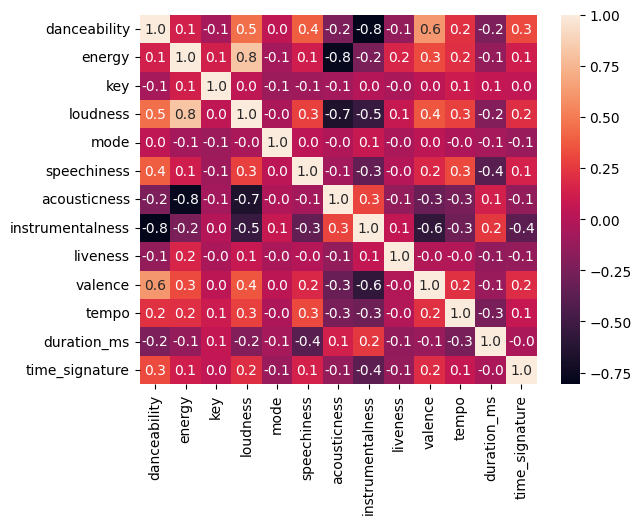

In [69]:
corr=x.corr()
sns.heatmap(corr,annot=True,fmt='0.01f')
#acousticness, loudness, instrumentalness on radar

<Axes: xlabel='key'>

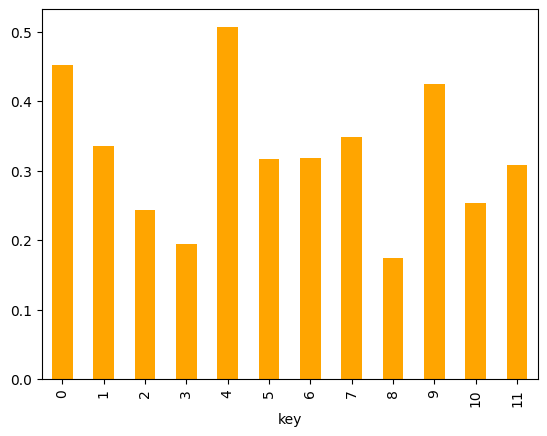

In [72]:
k=data.groupby("key")['acousticness'].mean()
k.plot(kind='bar',color='orange')

<Axes: xlabel='key'>

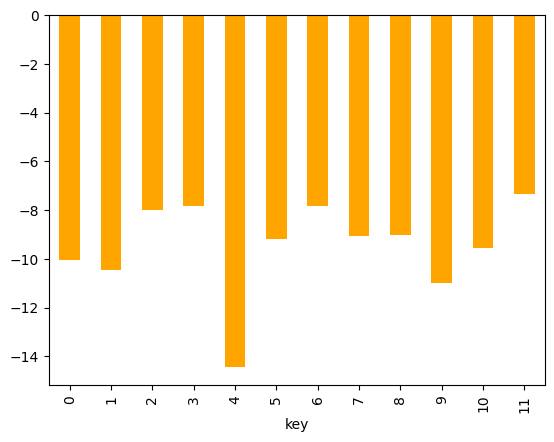

In [73]:
k=data.groupby("key")['loudness'].mean()
k.plot(kind='bar',color='orange')
#key number 4 is in highlight

<Axes: xlabel='mode'>

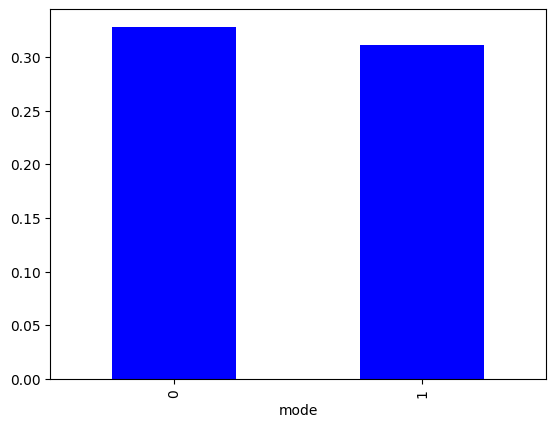

In [74]:
k=x.groupby("mode")['acousticness'].mean()
k.plot(kind='bar',color='blue')
#kinda useless

In [75]:
data['duration_ms'].mean()
#3:55 min

np.float64(213408.93333333332)

<Axes: xlabel='mode'>

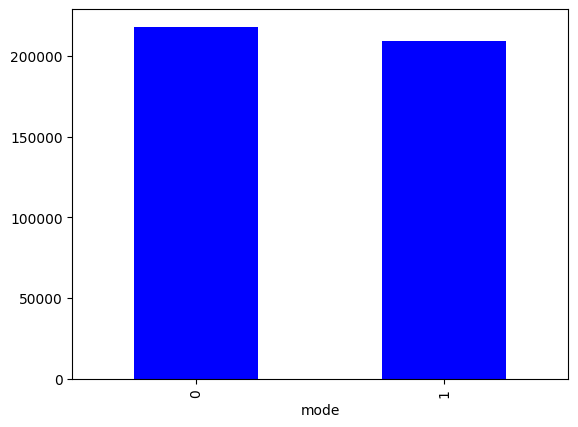

In [76]:
k=data.groupby("mode")['duration_ms'].mean()
k.plot(kind='bar',color='blue')

There are a lot of features and acousticness seems to be the most correlated identity so removing one shouldn't hinder the model much

In [77]:
x.drop("acousticness",axis=1,inplace=True)

In [133]:
x.shape

(195, 12)

In [78]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [79]:
import warnings
warnings.filterwarnings('ignore')

In [80]:
from sklearn.metrics import classification_report,f1_score,precision_score,recall_score,mean_squared_error,accuracy_score

In [113]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
p=lr.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))


accuracy: 0.8305084745762712
f1: 0.868421052631579
precision score: 0.8461538461538461
recall: 0.8918918918918919
mse: 0.1694915254237288


We can see, not that great of a result

In [82]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(x_train,y_train)
p=svc.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))


accuracy: 0.7288135593220338
f1: 0.7837837837837838
precision score: 0.7837837837837838
recall: 0.7837837837837838
mse: 0.2711864406779661


needs tunning

In [83]:
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}
grid=GridSearchCV(SVC(),param_grid)
grid.fit(x_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']})

In [84]:
print(grid.best_estimator_)

SVC(C=10, gamma=0.0001)


In [85]:
svc=SVC(C=10,gamma=0.001)
svc.fit(x_train,y_train)
p=svc.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.4067796610169492
f1: 0.14634146341463414
precision score: 0.75
recall: 0.08108108108108109
mse: 0.5932203389830508


Got worse, Bruhhhh

In [89]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion='gini',n_estimators=100)
rf.fit(x_train,y_train)
p=rf.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.9152542372881356
f1: 0.9315068493150684
precision score: 0.9444444444444444
recall: 0.918918918918919
mse: 0.0847457627118644


works great without tunning damn

In [96]:
rf=RandomForestClassifier(criterion='entropy',n_estimators=104,max_depth=None,min_samples_split=5)
rf.fit(x_train,y_train)
p=rf.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.9152542372881356
f1: 0.9315068493150684
precision score: 0.9444444444444444
recall: 0.918918918918919
mse: 0.0847457627118644


In [107]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(loss='log_loss',learning_rate=0.1, n_estimators=90)
gb.fit(x_train,y_train)
p=gb.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.8983050847457628
f1: 0.918918918918919
precision score: 0.918918918918919
recall: 0.918918918918919
mse: 0.1016949152542373


Not so cool

In [112]:
import xgboost as xgb
xgb=xgb.XGBClassifier(learning_rate=0.1,n_estimators=90)
xgb.fit(x_train,y_train)
p=xgb.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.9152542372881356
f1: 0.9315068493150684
precision score: 0.9444444444444444
recall: 0.918918918918919
mse: 0.0847457627118644


Random Forest and XGBoost has been the most useful so far

Infact both have same results

In [114]:
rf=RandomForestClassifier(criterion='entropy',n_estimators=104,max_depth=None,min_samples_split=5)
rf.fit(x_train,y_train)
p=rf.predict(x_test)
print('accuracy:',accuracy_score(y_test,p))
print("f1:",f1_score(y_test,p))
print('precision score:',precision_score(y_test,p))
print('recall:',recall_score(y_test,p))
print('mse:',mean_squared_error(y_test,p))

accuracy: 0.9152542372881356
f1: 0.9315068493150684
precision score: 0.9444444444444444
recall: 0.918918918918919
mse: 0.0847457627118644


So i am choosing RandomForest as my model

In [136]:
data.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


Testing

In [139]:
l=input("Enter features").split(',')

ll=np.array([l])
lll=input("Enter if you like the music 1-->yes 0-->no").split(',')

p=rf.predict(ll)
print("Your Opinion:",lll)
print("Prediction:",p)

Enter features0.357,0.98,6,-6.835,1,0.079,0.843,0.0768,0.368,96.969,242760,4
Enter if you like the music 1-->yes 0-->no0
Your Opinion: ['0']
Prediction: [0]
